## Importing the library

In [1]:
import os
import cv2
import numpy as np
import gc
import random
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, GlobalAveragePooling2D, Conv2D,
                                     MaxPooling2D, UpSampling2D, Concatenate, Multiply, Add, Activation, GlobalMaxPooling2D, Reshape)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from sklearn.utils import resample
from tensorflow.keras.callbacks import ModelCheckpoint


2025-07-30 16:03:11.097525: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753891391.343052      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753891391.411635      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Feature Extraction

In [2]:
def extract_roi(img, x_ratio, y_ratio, w_ratio, h_ratio):
    h_img, w_img = img.shape[:2]
    x = int(w_img * x_ratio)
    y = int(h_img * y_ratio)
    w = int(w_img * w_ratio)
    h = int(h_img * h_ratio)
    return img[y:y+h, x:x+w]

def preprocess_roi(roi):
    lab = cv2.cvtColor(roi, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    roi_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    sharpened = cv2.filter2D(roi_clahe, -1, kernel)
    return sharpened

def augment_image(img):
    flip = cv2.flip(img, 1)
    rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    return [flip, rotated]

def process_folder_roi(parent_dir, x_ratio, y_ratio, w_ratio, h_ratio, data_type='train'):
    X_real, X_tamp, y_real, y_tamp = [], [], [], []

    for folder in tqdm(os.listdir(parent_dir), desc=f"Processing {data_type} folders"):
        folder_path = os.path.join(parent_dir, folder)
        if not os.path.isdir(folder_path):
            continue

        label = 1 if "tampered" in folder.lower() else 0

        for filename in os.listdir(folder_path):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(folder_path, filename)
                img = cv2.imread(img_path)
                if img is None:
                    continue

                roi = extract_roi(img, x_ratio, y_ratio, w_ratio, h_ratio)
                roi = preprocess_roi(cv2.resize(roi, (224, 224)))

                if label == 1:
                    X_tamp.append(roi)
                    y_tamp.append(label)
                else:
                    X_real.append(roi)
                    y_real.append(label)

    # Only augment real images during testing
    if data_type == 'train':
        aug_real, aug_labels = [], []
        i = 0
        while len(X_real) + len(aug_real) < len(X_tamp) and i < len(X_real):
            augmented = augment_image(X_real[i])
            for aug in augmented:
                if len(X_real) + len(aug_real) < len(X_tamp):
                    aug_real.append(aug)
                    aug_labels.append(0)
            i += 1
        X_real.extend(aug_real)
        y_real.extend(aug_labels)

        # Balance the dataset if real > tampered (shouldn't happen in test now)
        if len(X_real) > len(X_tamp):
            X_real, y_real = resample(X_real, y_real, n_samples=len(X_tamp))

    X = np.array(X_real + X_tamp) 
    y = np.array(y_real + y_tamp)
    print(f"✅ Loaded {len(X)} ROI samples from {parent_dir} with {np.sum(y)} tampered and {len(y)-np.sum(y)} real.")
    return X, y

## Dataset Generation

In [3]:
# ==== Load Data ====
x_ref, y_ref, w_ref, h_ref = 1350, 200, 550, 650
x_ratio, y_ratio = x_ref / 1920, y_ref / 1080
w_ratio, h_ratio = w_ref / 1920, h_ref / 1080

data_dir_train = "/kaggle/input/tamper-train-set/kaggle/working/Tamper_Test"
data_dir_val = "/kaggle/input/mytest/Test"
data_dir_test="/kaggle/input/deptest/card_data 2"
X_train, y_train = process_folder_roi(data_dir_train, x_ratio, y_ratio, w_ratio, h_ratio)
X_val, y_val = process_folder_roi(data_dir_test, x_ratio, y_ratio, w_ratio, h_ratio, 'test')
X_test, y_test = process_folder_roi(data_dir_test, x_ratio, y_ratio, w_ratio, h_ratio, 'test')


Processing train folders: 100%|██████████| 2/2 [00:22<00:00, 11.30s/it]


✅ Loaded 1282 ROI samples from /kaggle/input/tamper-train-set/kaggle/working/Tamper_Test with 641 tampered and 641 real.


Processing test folders: 100%|██████████| 2/2 [00:54<00:00, 27.30s/it]


✅ Loaded 3714 ROI samples from /kaggle/input/deptest/card_data 2 with 642 tampered and 3072 real.


Processing test folders: 100%|██████████| 2/2 [00:26<00:00, 13.26s/it]


✅ Loaded 3714 ROI samples from /kaggle/input/deptest/card_data 2 with 642 tampered and 3072 real.


## Model Initialization

In [4]:
from tensorflow.keras.layers import Lambda

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Conv2D, UpSampling2D, Concatenate, GlobalAveragePooling2D, Dense, Lambda, Multiply, Reshape, Activation
from tensorflow.keras.models import Model

def cbam_block(input_feature, ratio=8):
    # Channel attention
    channel = input_feature.shape[-1]

    shared_dense_one = Dense(channel // ratio, activation='relu', kernel_initializer='he_normal', use_bias=True)
    shared_dense_two = Dense(channel, kernel_initializer='he_normal', use_bias=True)

    avg_pool = GlobalAveragePooling2D()(input_feature)
    avg_pool = Reshape((1, 1, channel))(avg_pool)
    avg_out = shared_dense_two(shared_dense_one(avg_pool))

    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=[1, 2], keepdims=True))(input_feature)
    max_out = shared_dense_two(shared_dense_one(max_pool))

    channel_attention = Activation('sigmoid')(avg_out + max_out)
    channel_refined = Multiply()([input_feature, channel_attention])

    # Spatial attention
    avg_pool_spatial = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_refined)
    max_pool_spatial = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_refined)
    concat = Concatenate(axis=-1)([avg_pool_spatial, max_pool_spatial])
    spatial_attention = Conv2D(1, kernel_size=7, strides=1, padding='same', activation='sigmoid')(concat)

    refined_feature = Multiply()([channel_refined, spatial_attention])
    return refined_feature

def build_fpn_cbam_model(input_shape=(224, 224, 3)):
    inputs = Input(shape=input_shape)
    base_model = MobileNetV2(include_top=False, weights='imagenet', input_tensor=inputs)

    # Extract features from multiple levels for FPN
    c1 = base_model.get_layer('block_3_expand_relu').output  # 56x56
    c2 = base_model.get_layer('block_6_expand_relu').output  # 28x28
    c3 = base_model.get_layer('block_13_expand_relu').output # 14x14
    c4 = base_model.get_layer('block_16_project').output     # 7x7

    # Project feature maps to same number of channels
    p4 = Conv2D(256, (1, 1), padding='same')(c4)
    p3 = Conv2D(256, (1, 1), padding='same')(c3)
    p2 = Conv2D(256, (1, 1), padding='same')(c2)
    p1 = Conv2D(256, (1, 1), padding='same')(c1)

    # Upsample and merge
    p3 = UpSampling2D(size=(2, 2))(p4)
    p3 = Concatenate()([p3, p3])
    p2 = UpSampling2D(size=(2, 2))(p3)
    p2 = Concatenate()([p2, p2])
    p1 = UpSampling2D(size=(2, 2))(p2)
    p1 = Concatenate()([p1, p1])

    # Merge all levels for a final FPN fusion
    merged = Concatenate()([UpSampling2D((8,8))(p4), UpSampling2D((4,4))(p3), UpSampling2D((2,2))(p2), p1])
    merged = Conv2D(256, (3, 3), padding='same', activation='relu')(merged)

    # Apply CBAM
    attention_output = cbam_block(merged)

    # Classification head
    x = GlobalAveragePooling2D()(attention_output)
    x = Dense(128, activation='relu')(x)
    x = Dense(1, activation='sigmoid')(x)

    return Model(inputs, x)

# Build and compile
model = build_fpn_cbam_model()
model.summary()

/tmp/ipykernel_19/1335080329.py:36: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(include_top=False, weights='imagenet', input_tensor=inputs)
I0000 00:00:1753891512.528568      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise_BN 

 Total params: 10,821,572 (41.28 MB)

 Trainable params: 10,790,660 (41.16 MB)

 Non-trainable params: 30,912 (120.75 KB)

## Model Training

In [5]:
for layer in model.layers:
    layer.trainable = True
callbacks = [EarlyStopping(patience=20, restore_best_weights=True, monitor='val_loss'),ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-7, monitor='val_loss'),ModelCheckpoint("best_model_finetuned.h5", save_best_only=True, monitor='val_loss')]
model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
history=model.fit(X_train, y_train,validation_data=(X_val, y_val),epochs=100,batch_size=32,callbacks=callbacks)
print(f"Best Training Accuracy: {max(history.history['accuracy'])*100:.2f}%")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

Epoch 1/100


I0000 00:00:1753891555.017760      64 service.cc:148] XLA service 0x7e7c7c033010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753891555.018658      64 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1753891558.589894      64 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-07-30 16:06:12.252845: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng11{k2=4,k3=0} for conv (f32[32,256,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3840,56,56]{3,2,1,0}, f32[256,3840,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-07-

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 852ms/step - accuracy: 0.5727 - loss: 0.6773

2025-07-30 16:07:40.407590: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng11{k2=4,k3=0} for conv (f32[32,256,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3840,56,56]{3,2,1,0}, f32[256,3840,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-07-30 16:07:40.914275: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.506815221s
Trying algorithm eng11{k2=4,k3=0} for conv (f32[32,256,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3840,56,56]{3,2,1,0}, f32[256,3840,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActiv

41/41 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.5751 - loss: 0.6754 - val_accuracy: 0.7329 - val_loss: 0.5628 - learning_rate: 1.0000e-04
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 27s 672ms/step - accuracy: 0.9018 - loss: 0.2575 - val_accuracy: 0.8549 - val_loss: 0.3848 - learning_rate: 1.0000e-04
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 26s 650ms/step - accuracy: 0.9778 - loss: 0.0518 - val_accuracy: 0.8710 - val_loss: 0.5532 - learning_rate: 1.0000e-04
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 27s 654ms/step - accuracy: 0.9929 - loss: 0.0205 - val_accuracy: 0.8875 - val_loss: 0.4767 - learning_rate: 1.0000e-04
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 27s 657ms/step - accuracy: 0.9898 - loss: 0.0309 - val_accuracy: 0.8627 - val_loss: 0.8267 - learning_rate: 1.0000e-04
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 27s 659ms/step - accuracy: 0.9971 - loss: 0.0095 - val_accuracy: 0.8578 - val_loss: 0.8324 - learning_rate: 1.0000e-04
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 27s 659ms/step - accuracy: 

## Model Evaluation

117/117 - 12s - 104ms/step - accuracy: 0.9381 - loss: 0.1678
✅ Test Accuracy: 93.81%
117/117 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      3072
           1       0.79      0.88      0.83       642

    accuracy                           0.94      3714
   macro avg       0.88      0.92      0.90      3714
weighted avg       0.94      0.94      0.94      3714



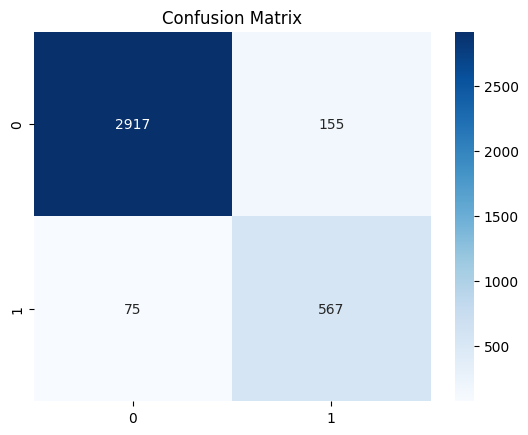

In [6]:
# ==== Evaluate ====
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"✅ Test Accuracy: {test_acc*100:.2f}%")

preds = model.predict(X_test)
pred_labels = (preds > 0.5).astype(int).flatten()
print(classification_report(y_test, pred_labels))

cm = confusion_matrix(y_test, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()